In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [3]:
!make clean
!make

rm -f test_parallel_for test_performance_threadpool_mostbusy test_performance_threadpool_random test_threadpool_steal_send_bilanciato test_threadpool_steal_send_sbilanciato test_threadpool_steal_send_sbilanciato_mostbusy test_threadpool_steal_send_sbilanciato_random 
g++  -std=c++20 -pthread -Wall -I../../../../  test_parallel_for.cpp -o test_parallel_for
g++  -std=c++20 -pthread -Wall -I../../../../  test_performance_threadpool_mostbusy.cpp -o test_performance_threadpool_mostbusy
g++  -std=c++20 -pthread -Wall -I../../../../  test_performance_threadpool_random.cpp -o test_performance_threadpool_random
g++  -std=c++20 -pthread -Wall -I../../../../  test_threadpool_steal_send_bilanciato.cpp -o test_threadpool_steal_send_bilanciato
g++  -std=c++20 -pthread -Wall -I../../../../  test_threadpool_steal_send_sbilanciato.cpp -o test_threadpool_steal_send_sbilanciato
g++  -std=c++20 -pthread -Wall -I../../../../  test_threadpool_steal_send_sbilanciato_mostbusy.cpp -o test_threadpool_steal_send

In [4]:
def run_test(test_name,n_runs = 200,n_elems = 16000,n_threads = 1):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $threads
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [33]:
def multi_plot(data1, data2, title, labels, n_threads):

    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    ticks = []

    for i in range(0,len(data1)):
        boxes.append(data1[i])
        boxes.append(data2[i])
        ticks.append(str(n_threads[i]))
        ticks.append(str(n_threads[i]))
        colors.append("peachpuff")
        colors.append("orange")

    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)
    # Etichette per gli assi
    ax.set_xticks(range(1,1+len(boxes)),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.legend([bplot["boxes"][0], bplot["boxes"][1]], [labels[0], labels[1]], loc='upper left')

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()

In [6]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[16,16])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()


In [7]:
def plot_speedup(data_list,title,num_threads):
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros_like(data_mean)

    for i in range(len(data_mean)):
        speedup[i] = data_mean[0]/data_mean[i]
        

    #print(data_list)
    #print(data_mean)
    ax.plot(num_threads,speedup,'o--')
    ax.plot(num_threads,num_threads)
    ax.legend(['speedup','maximum'])
    ax.set(title = title)


# Set number of runs

In [8]:
n_runs = 50

# Set number of threads

In [47]:
n_threads = [1,2,4,8]

# Set number of iterazioni ciclo for (lunghezza singolo job) 

In [10]:
n_elems = 100000

# Set test name

In [48]:
test_name = "test_performance_threadpool_"

# Test between random and most_busy

In [49]:
test_rand = [run_test(test_name+"random",n_runs,n_elems,n_thread)[0] for n_thread in n_threads]
test_most_busy = [run_test(test_name+"mostbusy",n_runs,n_elems,n_thread)[0] for n_thread in n_threads]

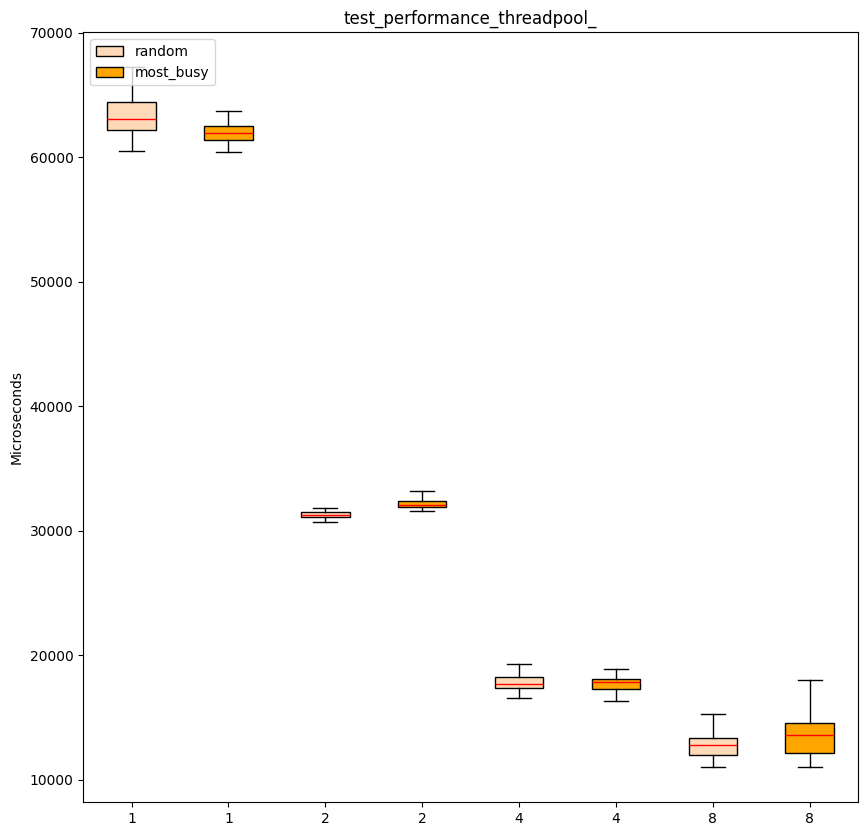

In [50]:
multi_plot(test_rand,test_most_busy,test_name,['random','most_busy'],n_threads)

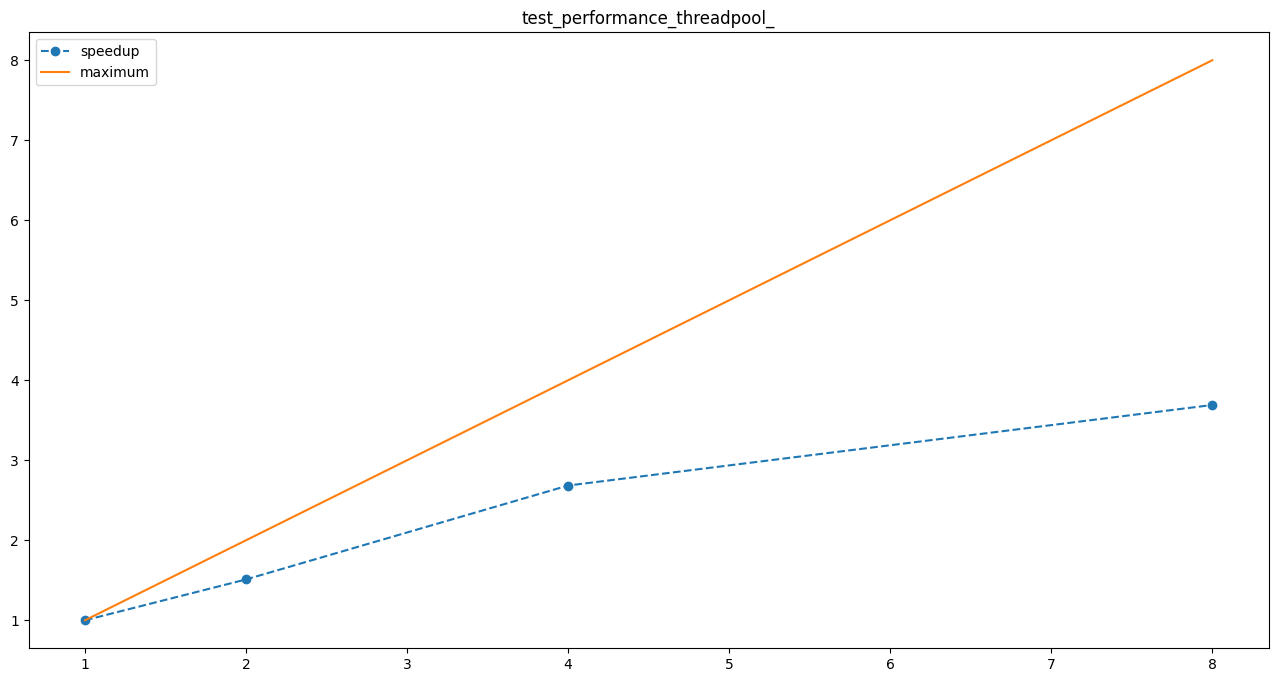

In [51]:
plot_speedup(test_rand,test_name,n_threads)

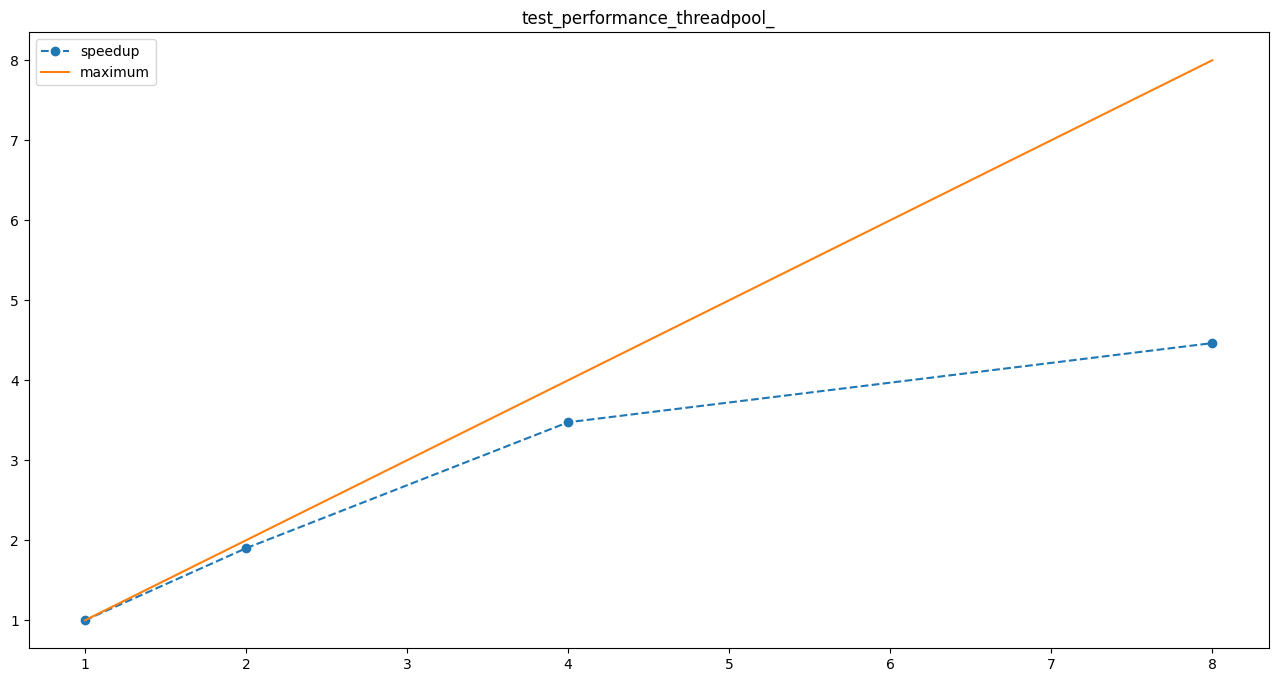

In [52]:
plot_speedup(test_most_busy,test_name,n_threads)

# steal: confronto metodi diversi con send dei job sbilanciati 

In [38]:
test_name = "test_threadpool_steal_send_sbilanciato_"

In [39]:
n_threads = [4,6,7,8]

In [40]:
test_random = run_test(test_name+"random",n_runs,n_elems,n_threads)


In [41]:
test_most_busy = run_test(test_name+"mostbusy",n_runs,n_elems,n_threads)

In [35]:
#test_random_most_busy = run_test(test_name,n_runs,n_elems,n_threads)

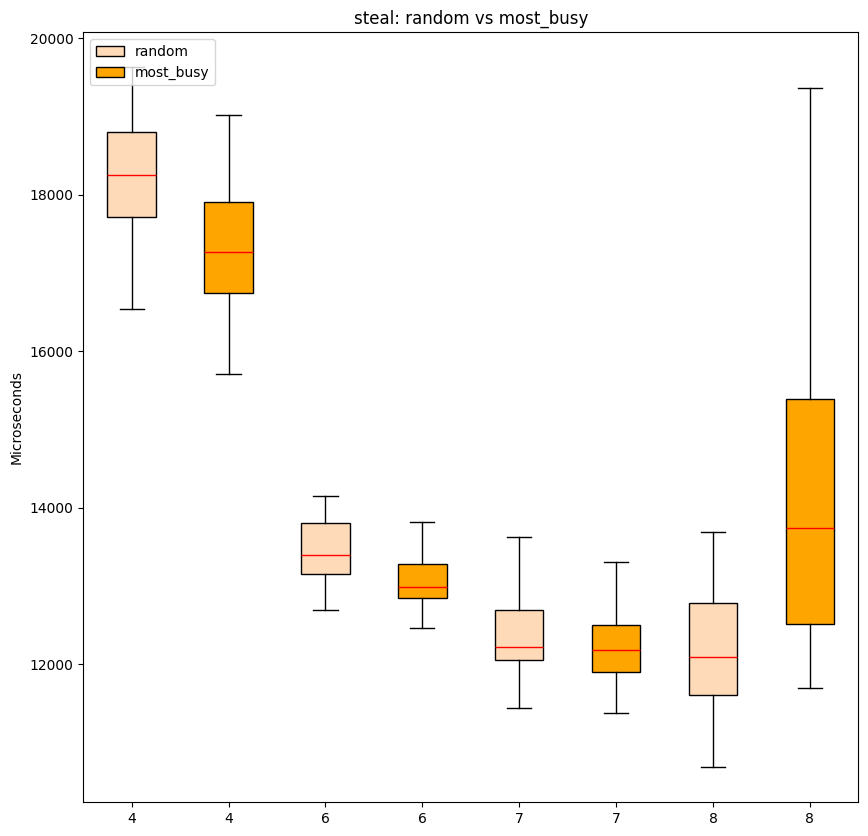

In [43]:
multi_plot(test_random,test_most_busy,"steal: random vs most_busy",["random","most_busy"],n_threads)

In [37]:
#multi_plot(test_most_busy,test_random_most_busy,"steal: most_busy vs random_most_busy",["most_busy","random_most_busy"])